In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cm
import pandas as pd
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# with open('../data/results/2026-08-30_15-58/all_trial_data.pkl', 'rb') as f:
#     all_trial_data = pickle.load(f)
with open('../data/results/2026-09-05_17-55_Morris/all_trial_data.pkl', 'rb') as f:
    all_trial_data = pickle.load(f)

In [2]:
Stiffness_Sis = []
Error_Sis = []
# Get a list of all the Stiffness Si data
for i, trial in enumerate(all_trial_data):
    Stiffness_Sis.append(trial['stiffness_Si'])
    Error_Sis.append(trial['error_Si'])

morris_problem = all_trial_data[0]['problem']

In [3]:
# iterate through each bush/branch/trial combination and print the field stiffness
with open('../data/results/2026-09-04_23-30_naive/metadata.pkl', 'rb') as f:
    naive_metadata = pickle.load(f)

naive_metadata = pd.DataFrame(naive_metadata)
print(naive_metadata['bush'].unique())

for trial in all_trial_data:
    # get the field stiffness     
    field_stiffness = naive_metadata[(naive_metadata['bush'] == trial['bush']) & (naive_metadata['branch'] == trial['branch']) & (naive_metadata['trial'] == trial['trial'])]['field_stiffness'].values[0]
    print(f"Bush: {trial['bush']}, Branch: {trial['branch']}, Trial: {trial['trial']}, Field Stiffness: {field_stiffness}")
    sim_stiffnesses = trial['output_stiffnesses']
    directional_smape_errors = np.zeros_like(sim_stiffnesses)
    angle_between = np.zeros_like(sim_stiffnesses)
    for i, sim_stiffness in enumerate(sim_stiffnesses):
        directional_smape_errors[i] = 2*np.abs(sim_stiffness - field_stiffness) / (sim_stiffness + field_stiffness)
        angle_between[i] = np.arctan2(np.abs(sim_stiffness-field_stiffness), np.abs(1+sim_stiffness*field_stiffness))*180/np.pi 

    print(f"angle between slopes: {angle_between}")
    print(f"saved errors: {trial['output_errors']}")

[ 1  3  5  9 14 23]
Bush: 1, Branch: 1, Trial: 1, Field Stiffness: 0.017082693407446378
angle between slopes: [0.84789255 0.72856499 0.6892255  0.77780721 0.61626833 0.8942475
 0.87683253 0.90108831 0.92713168 0.80805125 0.80805125 0.92713168
 0.90108831 0.91286425 0.8942475  0.87349019 0.77780721 0.6892255
 0.5445743  0.6318443 ]
saved errors: [1.52853206 1.18589647 1.08706905 1.31888979 0.91913321 1.68237617
 1.62303105 1.70622291 1.79990643 1.40622134 1.40622134 1.79990643
 1.70622291 1.74800489 1.68237617 1.61185943 1.31888979 1.08706905
 0.77099901 0.95343479]
Bush: 1, Branch: 1, Trial: 2, Field Stiffness: 0.032696936658287545
angle between slopes: [1.7278899  1.68375066 1.77121659 1.54658256 1.588395   1.23283977
 1.37331468 1.25053033 1.40479176 1.62753977 1.8041806  1.76717315
 1.74258144 1.45910877 1.23908908 1.53295908 1.38174546 1.35857517
 1.6494764  1.57634283]
saved errors: [1.71293806 1.63347258 1.79439499 1.40687734 1.47289751 0.98155744
 1.15808789 1.00269521 1.2005483

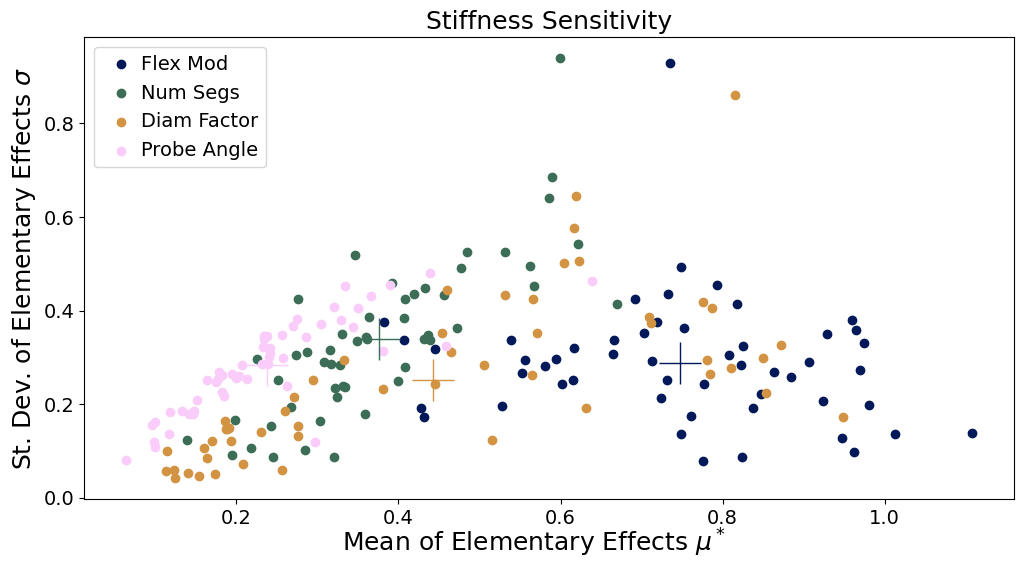

In [4]:

# make a scatterplot with mu star on the x axis and sigma on the y axis for each parameter, for both stiffness and error
# each parameter should be a different color. The stiffness and error will be on different plots. 
plt.close('all')
full_variable_names = ["Flex Mod", "Num Segs", "Diam Factor", "Probe Angle"]
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = [cm.batlow(x) for x in np.linspace(0, 1, len(morris_problem['names']))]
for i, name in enumerate(morris_problem['names']):
    for j in range(len(Stiffness_Sis)):
        ax.scatter(Stiffness_Sis[j]['mu_star'][i], Stiffness_Sis[j]['sigma'][i],
                    color=colors[i], label=name if j == 0 else None)
        # ax[1].scatter(Error_Sis[j]['mu_star'][i], Error_Sis[j]['sigma'][i],
        #             color=colors[i], label=name if j == 0 else None)

# get mean of the stiffness and error sensitivity indices for each parameter and plot them as a line on the scatterplot
mean_stiffness_Sis = {name: {'mu_star': [], 'sigma': []} for name in morris_problem['names']}
mean_error_Sis = {name: {'mu_star': [], 'sigma': []} for name in morris_problem['names']}
for i, name in enumerate(morris_problem['names']):
    for j in range(len(Stiffness_Sis)):
        mean_stiffness_Sis[name]['mu_star'].append(Stiffness_Sis[j]['mu_star'][i])
        mean_stiffness_Sis[name]['sigma'].append(Stiffness_Sis[j]['sigma'][i])
        mean_error_Sis[name]['mu_star'].append(Error_Sis[j]['mu_star'][i])
        mean_error_Sis[name]['sigma'].append(Error_Sis[j]['sigma'][i])
    ax.plot(np.mean(mean_stiffness_Sis[name]['mu_star']), np.mean(mean_stiffness_Sis[name]['sigma']),
                color=colors[i], marker='+', markersize=30, label=name)
    # ax[1].plot(np.mean(mean_error_Sis[name]['mu_star']), np.mean(mean_error_Sis[name]['sigma']),
    #             color=colors[i], marker='+', markersize=30, label=name)
ax.set_title('Stiffness Sensitivity', fontsize=18)
ax.set_ylabel('St. Dev. of Elementary Effects $\sigma$', fontsize=18)
# ax[1].set_title('Error Sensitivity (sMAPE)', fontsize=18)
fig.supxlabel('Mean of Elementary Effects $\mu^*$', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=14)
# ax[1].tick_params(axis='both', which='major', labelsize=14)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[0:4], full_variable_names, fontsize=14, handletextpad=0.01, loc='upper left')
# fig.tight_layout(rect=[0, 0, 0.82, 1])  # leave room on the right for the legend
plt.savefig(f"../images/sensitivity_analysis_v1_3.pdf", dpi=300)
plt.show()


In [10]:
# show a table of the bush #, branch #, trial #, and diam factor mean mu star. 
mask = []
for trial in all_trial_data:
    if trial['stiffness_Si']['mu_star'][2] > 0.5:
        mask.append(True)
    else:
        mask.append(False)
    print(f"Bush {trial['bush']}, Branch {trial['branch']}, Trial {trial['trial']}, Mu Star: {trial['stiffness_Si']['mu_star'][2]:.4f}")  

with open('../data/results/2026-08-18_16-12/mask.pkl', 'wb') as f:
    pickle.dump(mask, f)

# print(mask)


Bush 1, Branch 1, Trial 1, Mu Star: 0.2565
Bush 1, Branch 1, Trial 2, Mu Star: 0.2303
Bush 1, Branch 1, Trial 3, Mu Star: 0.1644
Bush 1, Branch 2, Trial 1, Mu Star: 0.5057
Bush 1, Branch 2, Trial 2, Mu Star: 0.2948
Bush 1, Branch 2, Trial 3, Mu Star: 0.1906
Bush 1, Branch 3, Trial 1, Mu Star: 0.8104
Bush 1, Branch 3, Trial 2, Mu Star: 0.6187
Bush 1, Branch 3, Trial 3, Mu Star: 0.8156
Bush 3, Branch 1, Trial 1, Mu Star: 0.7751
Bush 3, Branch 1, Trial 2, Mu Star: 0.7849
Bush 3, Branch 1, Trial 3, Mu Star: 0.7118
Bush 3, Branch 2, Trial 1, Mu Star: 0.8494
Bush 3, Branch 2, Trial 2, Mu Star: 0.9480
Bush 3, Branch 2, Trial 3, Mu Star: 0.8717
Bush 3, Branch 3, Trial 1, Mu Star: 0.1888
Bush 3, Branch 3, Trial 2, Mu Star: 0.1409
Bush 3, Branch 3, Trial 3, Mu Star: 0.2755
Bush 5, Branch 1, Trial 1, Mu Star: 0.5316
Bush 5, Branch 1, Trial 2, Mu Star: 0.7808
Bush 5, Branch 1, Trial 3, Mu Star: 0.7089
Bush 5, Branch 2, Trial 1, Mu Star: 0.5155
Bush 5, Branch 2, Trial 2, Mu Star: 0.5663
Bush 5, Bra

B1/B1/T1, Min Error: 77.1%
Flex mod: 8050000000.00, Num Segs: 13.2, Diam Factor: 1.00, Probe Angle: -0.52
B1/B1/T2, Min Error: 98.2%
Flex mod: 8050000000.00, Num Segs: 9.8, Diam Factor: 0.60, Probe Angle: 0.52
B1/B1/T3, Min Error: 60.6%
Flex mod: 8050000000.00, Num Segs: 13.2, Diam Factor: 1.00, Probe Angle: -0.52
B1/B2/T1, Min Error: 1.4%
Flex mod: 1820000000.00, Num Segs: 20.0, Diam Factor: 1.00, Probe Angle: 0.10
B1/B2/T2, Min Error: 10.4%
Flex mod: 1820000000.00, Num Segs: 9.8, Diam Factor: 0.60, Probe Angle: 0.52
B1/B2/T3, Min Error: 1.1%
Flex mod: 1820000000.00, Num Segs: 9.8, Diam Factor: 1.00, Probe Angle: -0.52
B1/B3/T1, Min Error: 4.2%
Flex mod: 1820000000.00, Num Segs: 3.0, Diam Factor: 1.00, Probe Angle: -0.52
B1/B3/T2, Min Error: 12.2%
Flex mod: 1820000000.00, Num Segs: 13.2, Diam Factor: 0.40, Probe Angle: -0.52
B1/B3/T3, Min Error: 1.1%
Flex mod: 4312000000.00, Num Segs: 3.0, Diam Factor: 0.00, Probe Angle: 0.52
B3/B1/T1, Min Error: 6.4%
Flex mod: 5558000000.00, Num Segs

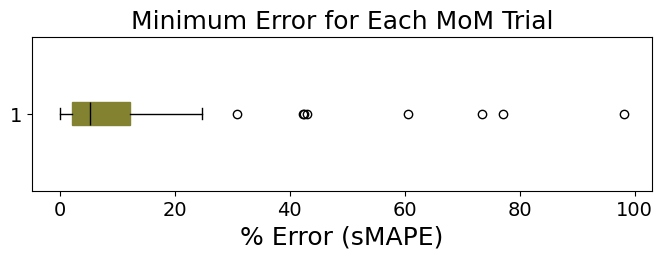

In [11]:
# --------------- answer: for each trial, how low did the error get? ------------
min_errors = []
for trial in all_trial_data:
    min_idx = np.argmin(trial['output_errors'])
    min_error = np.min(trial['output_errors'])
    min_errors.append(min_error*100)
    print(f"B{trial['bush']}/B{trial['branch']}/T{trial['trial']}, Min Error: {(min_error*100):.1f}%")
    print(f"Flex mod: {trial['samples'][min_idx][0]:.2f}, Num Segs: {trial['samples'][min_idx][1]:.1f}, Diam Factor: {trial['samples'][min_idx][2]:.2f}, Probe Angle: {trial['samples'][min_idx][3]:.2f}")
    # print(trial['samples'][min_idx])

fig, ax = plt.subplots(1, 1, figsize=(8, 2))
ax.boxplot(min_errors, vert=False, patch_artist=True, boxprops=dict(facecolor=cm.batlow(0.5), color=cm.batlow(0.5)), medianprops=dict(color='black'))
ax.set_title('Minimum Error for Each MoM Trial', fontsize=18)
ax.set_xlabel('% Error (sMAPE)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=14)
plt.show()